Raw Data Points (First 10): [(346, 588), (346, 589), (665, 586), (666, 587), (668, 587), (667, 587), (666, 586), (650, 586), (651, 587), (653, 587)]


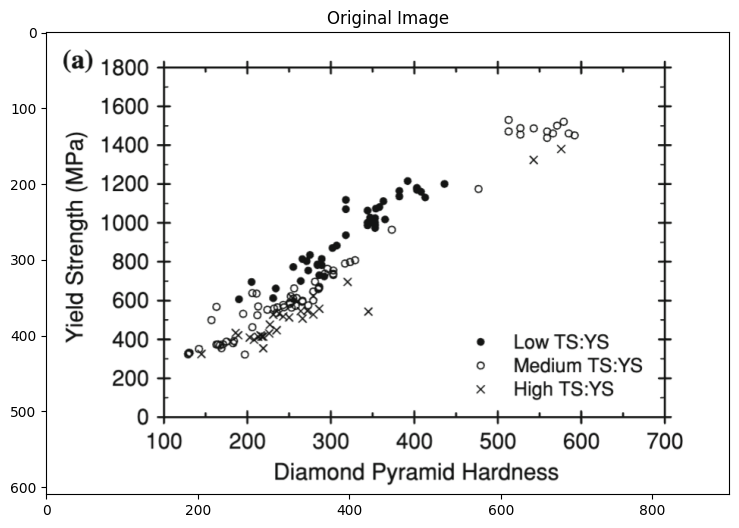

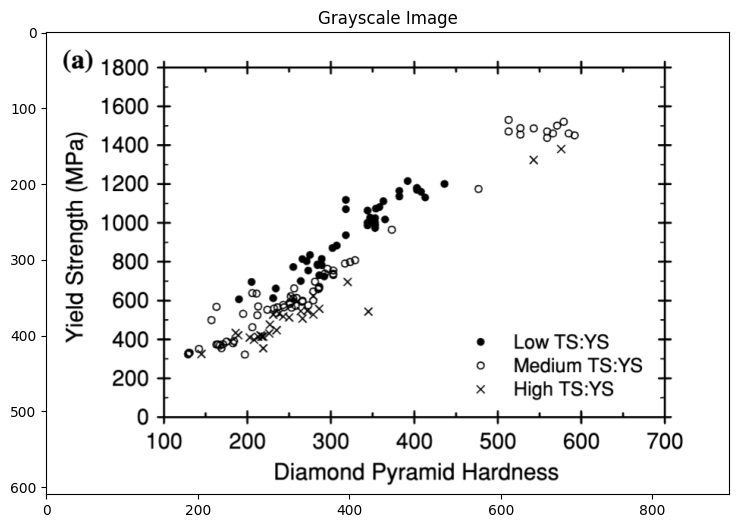

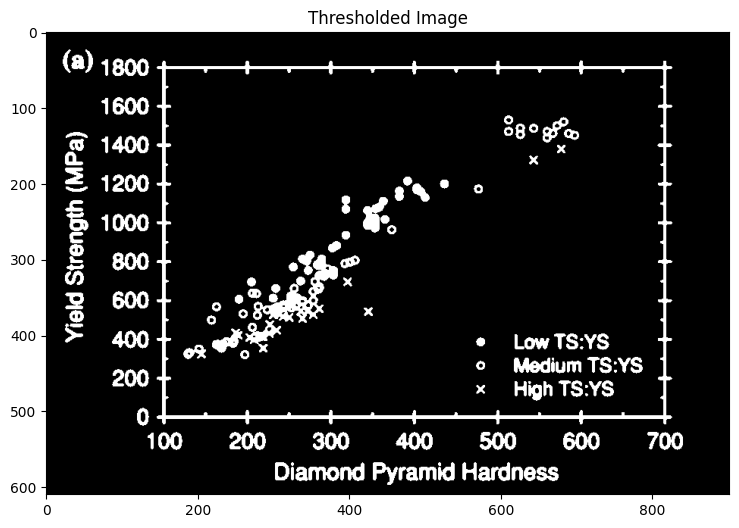

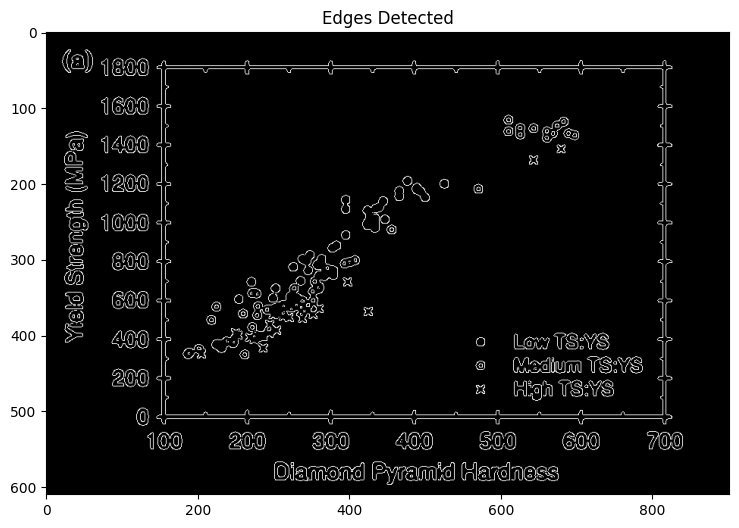

Filtered Data Points (First 10): []


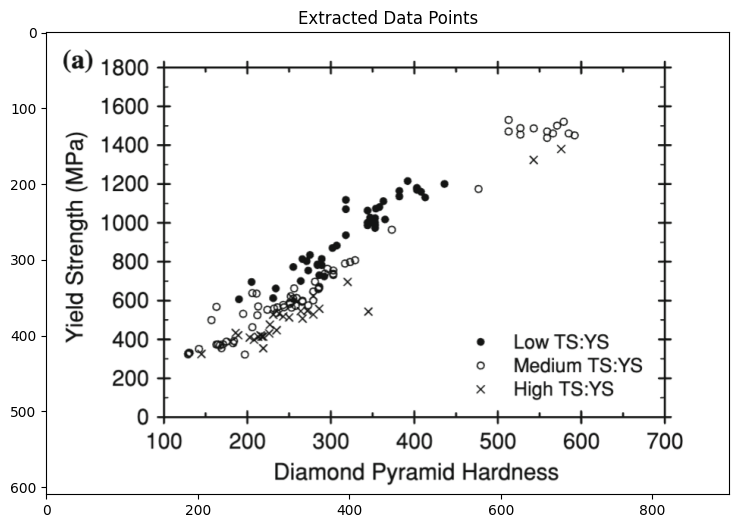

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image_path = "graph3.png"  # Replace with your file path
image = cv2.imread(image_path)

# Step 1: Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Step 2: Apply GaussianBlur to reduce noise
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Step 3: Apply binary thresholding for better point isolation
_, thresh = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY_INV)  # Adjust threshold value if needed

# Step 4: Apply edge detection
edges = cv2.Canny(thresh, threshold1=50, threshold2=150)  # Adjust thresholds as needed

# Step 5: Find contours in the edge-detected image
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Step 6: Extract data points from contours
data_points = []
for contour in contours:
    for point in contour:
        x, y = point[0]
        data_points.append((x, y))

# Debugging: Print raw pixel coordinates of detected points
print("Raw Data Points (First 10):", data_points[:10])

# Step 7: Define axis limits (calibrated manually based on the graph)
x_pixel_min, x_pixel_max = 100, 700  # Pixel range for X-axis (manually calibrated)
y_pixel_min, y_pixel_max = 500, 50   # Pixel range for Y-axis (manually calibrated; inverted)

x_value_min, x_value_max = 100, 700  # Actual X-axis values from the graph
y_value_min, y_value_max = 2000, 100 # Actual Y-axis values from the graph

# Step 8: Map pixel coordinates to graph values using linear interpolation
mapped_data_points = [
    (
        np.interp(x, [x_pixel_min, x_pixel_max], [x_value_min, x_value_max]),
        np.interp(y, [y_pixel_min, y_pixel_max], [y_value_min, y_value_max])
    )
    for x, y in data_points
]

# Step 9: Filter out points outside the graph range (optional)
filtered_data_points = [
    (x, y) for x, y in mapped_data_points if x_value_min <= x <= x_value_max and y_value_min <= y <= y_value_max
]

# Debugging visualizations to check intermediate steps
plt.figure(figsize=(10, 6))
plt.title("Original Image")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()

plt.figure(figsize=(10, 6))
plt.title("Grayscale Image")
plt.imshow(gray, cmap='gray')
plt.show()

plt.figure(figsize=(10, 6))
plt.title("Thresholded Image")
plt.imshow(thresh, cmap='gray')
plt.show()

plt.figure(figsize=(10, 6))
plt.title("Edges Detected")
plt.imshow(edges, cmap='gray')
plt.show()

# Output filtered data points (first few points for verification)
print("Filtered Data Points (First 10):", filtered_data_points[:10])

# Optional: Plot the extracted points on the original image for verification
x_graph_values = [point[0] for point in filtered_data_points]
y_graph_values = [point[1] for point in filtered_data_points]

plt.figure(figsize=(10, 6))
plt.title("Extracted Data Points")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.scatter(
    np.interp(x_graph_values, [x_value_min, x_value_max], [x_pixel_min, x_pixel_max]),
    np.interp(y_graph_values, [y_value_min, y_value_max], [y_pixel_min, y_pixel_max]),
    color='red',
    s=5
)
plt.show()
